# QS Asian University Rankings Analysis 

### Objective
The goal of this project is to explore the QS Asian University Ranking
and identify patterns and insights about top universities in Asia.

### Dataset
Source: Kaggle - QS Asian University Rankings

### Tools
- Python
- Pandas
- Matplotlib
- Seaborn

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# read csv
df = pd.read_csv("/Users/pat/Documents/Project/University Analysis/topuniversities.csv")

## Dataset Overview

This dataset contains the top universities in Asia based on QS rankings.

Important columns include:
- Country
- Overall Score
- Academic Reputation
- Citations per Paper
- Papers per Faculty

In [17]:
# check the top 5 data
df.head()

,Rank,Ordinal Rank,University Name,Overall Score,City,Country,Citations per Paper,Papers per Faculty,Academic Reputation,Faculty Student Ratio,Staff with PhD,International Research Center,International Students,Outbound Exchange,Inbound Exchange,International Faculty,Employer Reputation
0,1,1,Peking University,100.0,Beijing,China,96.4,79.8,100.0,98.6,90.7,98.0,69.1,100.0,88.5,83.2,100.0
1,2,2,The University of Hong Kong,99.7,Pokfulam,Hong Kong,99.5,55.0,100.0,93.3,97.4,98.4,100.0,100.0,99.8,100.0,96.8
2,3,3,National University of Singapore (NUS),98.9,Singapore,Singapore,99.9,57.4,100.0,85.8,82.5,99.9,99.2,97.6,93.4,100.0,99.9
3,4,4,Nanyang Technological University,98.3,Singapore,Singapore,100.0,53.8,100.0,93.0,67.0,99.7,98.8,97.9,90.5,100.0,98.8
4,5,5,Fudan University,97.2,Shanghai,China,92.1,63.1,99.8,92.5,73.4,92.1,81.0,94.9,99.5,98.9,99.5


In [18]:
# check the latest 5 data
df.tail()

,Rank,Ordinal Rank,University Name,Overall Score,City,Country,Citations per Paper,Papers per Faculty,Academic Reputation,Faculty Student Ratio,Staff with PhD,International Research Center,International Students,Outbound Exchange,Inbound Exchange,International Faculty,Employer Reputation
295,296,296,National Chinyi University of Technology,29.5,Taichung City,Taiwan,25.8,15.9,31.9,12.9,52.1,11.5,29.8,3.4,17.2,5.1,46.7
296,297,296,Sungshin Women's University,29.5,Seoul,South Korea,9.1,2.1,21.4,93.0,18.6,2.5,22.5,85.5,44.6,7.7,33.9
297,298,298,Northwest University (China),29.2,Xi'an,China,64.5,27.4,16.1,69.5,17.5,49.7,13.3,47.9,6.1,10.6,5.3
298,299,299,Ocean University of China,29.1,Qingdao,China,48.1,60.5,20.8,13.9,33.0,76.4,6.5,27.3,2.8,8.5,12.4
299,300,300,Huazhong Agricultural University,29.0,Wuhan,China,91.5,52.2,16.7,12.1,61.0,45.6,6.6,11.5,1.5,11.7,9.3


In [19]:
# check the structure
df.shape

(300, 17)

### Data Types

This step verifies that each column has the correct data type
for analysis (numeric, categorical, etc.).

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Rank                           300 non-null    int64  
 1   Ordinal Rank                   300 non-null    int64  
 2   University Name                300 non-null    object 
 3   Overall Score                  300 non-null    float64
 4   City                           300 non-null    object 
 5   Country                        300 non-null    object 
 6   Citations per Paper            300 non-null    float64
 7   Papers per Faculty             300 non-null    float64
 8   Academic Reputation            300 non-null    float64
 9   Faculty Student Ratio          300 non-null    float64
 10  Staff with PhD                 294 non-null    float64
 11  International Research Center  300 non-null    float64
 12  International Students         296 non-null    flo

## Research Questions

This analysis aims to answer the following questions:

1. Which countries have the most universities in the ranking?
2. How are university scores distributed?
3. What factors correlate with university rankings?
4. Are research metrics related to overall scores?

## Data Cleaning

### Missing Values

This step checks whether there are missing values in the dataset.
Handling missing values is important because they may affect analysis results.

In [21]:
df.isnull().sum()

Rank                              0
Ordinal Rank                      0
University Name                   0
Overall Score                     0
City                              0
Country                           0
Citations per Paper               0
Papers per Faculty                0
Academic Reputation               0
Faculty Student Ratio             0
Staff with PhD                    6
International Research Center     0
International Students            4
Outbound Exchange                 0
Inbound Exchange                  0
International Faculty            17
Employer Reputation               0
dtype: int64

In [22]:
df = df.dropna()
df

,Rank,Ordinal Rank,University Name,Overall Score,City,Country,Citations per Paper,Papers per Faculty,Academic Reputation,Faculty Student Ratio,Staff with PhD,International Research Center,International Students,Outbound Exchange,Inbound Exchange,International Faculty,Employer Reputation
0,1,1,Peking University,100.0,Beijing,China,96.4,79.8,100.0,98.6,90.7,98.0,69.1,100.0,88.5,83.2,100.0
1,2,2,The University of Hong Kong,99.7,Pokfulam,Hong Kong,99.5,55.0,100.0,93.3,97.4,98.4,100.0,100.0,99.8,100.0,96.8
2,3,3,National University of Singapore (NUS),98.9,Singapore,Singapore,99.9,57.4,100.0,85.8,82.5,99.9,99.2,97.6,93.4,100.0,99.9
3,4,4,Nanyang Technological University,98.3,Singapore,Singapore,100.0,53.8,100.0,93.0,67.0,99.7,98.8,97.9,90.5,100.0,98.8
4,5,5,Fudan University,97.2,Shanghai,China,92.1,63.1,99.8,92.5,73.4,92.1,81.0,94.9,99.5,98.9,99.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,296,National Chinyi University of Technology,29.5,Taichung City,Taiwan,25.8,15.9,31.9,12.9,52.1,11.5,29.8,3.4,17.2,5.1,46.7
296,297,296,Sungshin Women's University,29.5,Seoul,South Korea,9.1,2.1,21.4,93.0,18.6,2.5,22.5,85.5,44.6,7.7,33.9
297,298,298,Northwest University (China),29.2,Xi'an,China,64.5,27.4,16.1,69.5,17.5,49.7,13.3,47.9,6.1,10.6,5.3
298,299,299,Ocean University of China,29.1,Qingdao,China,48.1,60.5,20.8,13.9,33.0,76.4,6.5,27.3,2.8,8.5,12.4


### Duplicate Records

Duplicate rows were checked to ensure data consistency.

In [23]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.

## Exploratory Data Analysis

This section explores the dataset to understand the distribution
of variables and identify patterns in university rankings.

### Summary Statistics

Basic statistics such as mean, minimum, and maximum values
were examined to understand the distribution of numerical variables.

In [24]:
df.describe()

,Rank,Ordinal Rank,Overall Score,Citations per Paper,Papers per Faculty,Academic Reputation,Faculty Student Ratio,Staff with PhD,International Research Center,International Students,Outbound Exchange,Inbound Exchange,International Faculty,Employer Reputation
count,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000,282.000000
mean,145.652482,145.287234,53.022340,44.076241,40.898582,53.048227,51.684397,53.729078,60.435106,37.227305,40.365603,36.984397,38.561348,55.970922
std,86.185143,85.996022,19.251825,34.246873,30.147239,26.212242,30.870763,35.046105,31.508905,31.513777,34.308773,36.184712,30.554163,29.865648
min,1.000000,1.000000,29.000000,1.000000,1.200000,8.800000,2.600000,1.000000,1.100000,1.400000,1.000000,1.000000,1.000000,4.200000
25%,71.250000,71.250000,36.300000,10.125000,14.025000,32.650000,22.675000,15.200000,32.525000,10.725000,9.975000,4.525000,12.850000,30.550000
50%,142.500000,142.500000,48.850000,38.150000,34.750000,46.450000,49.000000,62.300000,68.400000,26.300000,31.950000,23.950000,29.550000,54.200000
75%,219.750000,219.000000,65.100000,75.950000,62.325000,71.725000,80.225000,85.575000,89.150000,62.525000,66.950000,72.375000,56.875000,82.800000
max,300.000000,300.000000,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [25]:
top_uni = df[df['Overall Score'] == df['Overall Score'].max()]
top_uni

,Rank,Ordinal Rank,University Name,Overall Score,City,Country,Citations per Paper,Papers per Faculty,Academic Reputation,Faculty Student Ratio,Staff with PhD,International Research Center,International Students,Outbound Exchange,Inbound Exchange,International Faculty,Employer Reputation
0,1,1,Peking University,100.0,Beijing,China,96.4,79.8,100.0,98.6,90.7,98.0,69.1,100.0,88.5,83.2,100.0


In [26]:
worse_uni = df[df['Overall Score'] == df['Overall Score'].min()]
worse_uni

,Rank,Ordinal Rank,University Name,Overall Score,City,Country,Citations per Paper,Papers per Faculty,Academic Reputation,Faculty Student Ratio,Staff with PhD,International Research Center,International Students,Outbound Exchange,Inbound Exchange,International Faculty,Employer Reputation
299,300,300,Huazhong Agricultural University,29.0,Wuhan,China,91.5,52.2,16.7,12.1,61.0,45.6,6.6,11.5,1.5,11.7,9.3


## Data Visualization

Visualizations are used to better understand the distribution
of universities and relationships between ranking factors.

In [42]:
# define the data before visualization by grouping
country_counts = df['Country'].value_counts()
country_counts

Country
China          60
India          34
South Korea    32
Japan          27
Malaysia       25
Taiwan         18
Indonesia      13
Kazakhstan     13
Pakistan       11
Thailand        9
Iran            8
Hong Kong       7
Philippines     4
Bangladesh      4
Vietnam         4
Singapore       3
Kyrgystan       3
Brunei          2
Macau SAR       2
Uzbekistan      2
Sri Lanka       1
Name: count, dtype: int64

## Bar Chart

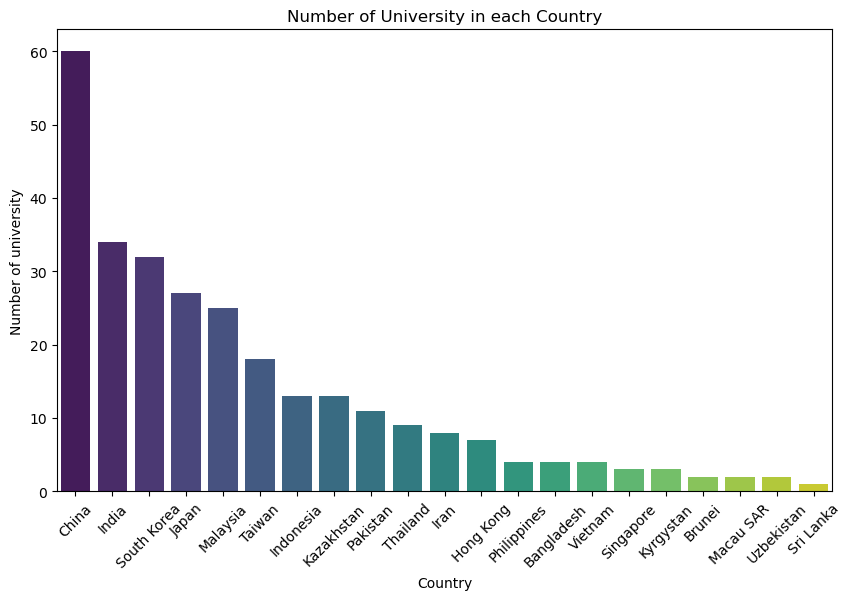

In [43]:
plt.figure(figsize = (10, 6))
sns.barplot(x = country_counts.index, 
           y = country_counts.values,
           hue = country_counts.index,
           palette='viridis',
           legend=False)
plt.title("Number of University in each Country")
plt.xlabel("Country")
plt.ylabel("Number of university")
plt.xticks(rotation = 45)
plt.show()

### Insight
China appears to have the largest number of universities in the ranking.

## Scatter Plot

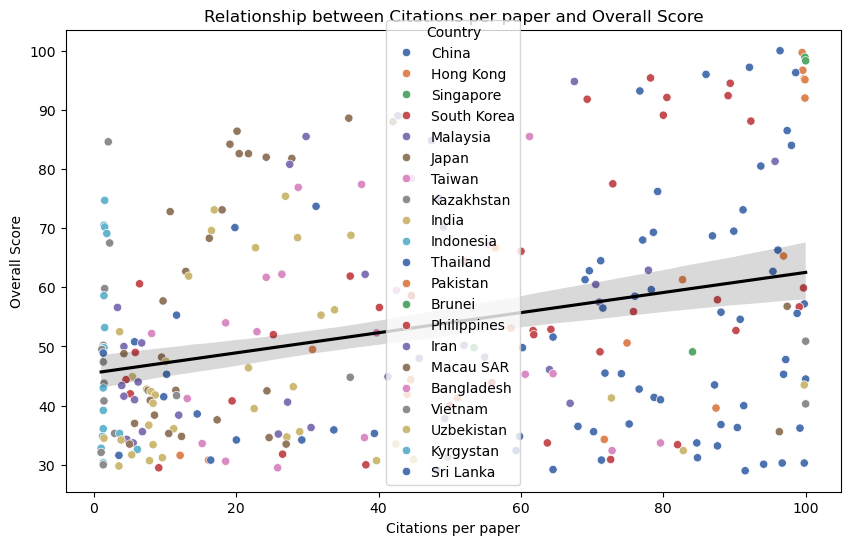

In [37]:
plt.figure(figsize = (10, 6))
sns.scatterplot(x = "Citations per Paper", 
               y = "Overall Score", 
               hue = "Country",
               data = df,
               palette = "deep")

sns.regplot(
    x="Citations per Paper",
    y="Overall Score",
    data=df,
    scatter=False,   
    color="black"   
)

plt.title("Relationship between Citations per paper and Overall Score")
plt.xlabel("Citations per paper")
plt.ylabel("Overall Score")
plt.show()

### Insight

The scatter plot displays a positive relationship between citations per paper
and the overall university score.

Universities with higher research impact (more citations per paper)
tend to have higher overall scores. This indicates that research output
and academic influence may play an important role in university rankings.

## Box Plot

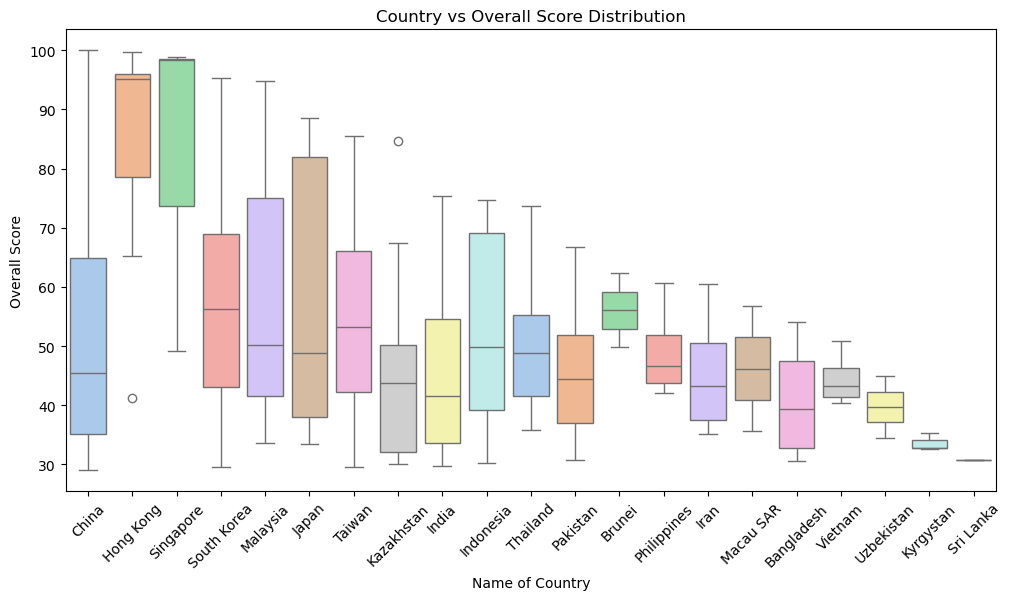

In [39]:
plt.figure(figsize = (12, 6))
sns.boxplot(x = "Country",
           y = "Overall Score",
           hue="Country",
           data=df,
           palette="pastel",
           legend=False)

plt.title("Country vs Overall Score Distribution")
plt.xlabel("Name of Country")
plt.ylabel("Overall Score")
plt.xticks(rotation = 45)
plt.show()

### Insight

The box plot shows the distribution of overall university scores across different countries.

Singapore and Hong Kong have the highest median scores, indicating that universities
in these countries tend to perform very well in the rankings.

Some countries such as China and Japan show a wider spread of scores,
suggesting a larger variation in university performance.

In contrast, several countries have scores concentrated in the mid-range,
around 40–60, indicating more moderate ranking performance.

## Correlation Analysis

Correlation analysis is used to examine the relationship between
different numerical variables in the dataset. 

The correlation matrix helps identify which factors are most
associated with the overall university score.

In [45]:
# select only numeric data
corr_df = df[['Overall Score', 
'Citations per Paper', 
'Papers per Faculty', 
'Academic Reputation', 
'Faculty Student Ratio',
'Staff with PhD',
'International Research Center',
'International Students',
'Outbound Exchange',
'Inbound Exchange',
'International Faculty',
'Employer Reputation']]

In [46]:
# find correlation values
corr_df.corr()

,Overall Score,Citations per Paper,Papers per Faculty,Academic Reputation,Faculty Student Ratio,Staff with PhD,International Research Center,International Students,Outbound Exchange,Inbound Exchange,International Faculty,Employer Reputation
Overall Score,1.000000,0.302392,0.334776,0.896712,0.467353,0.476719,0.497246,0.498245,0.387442,0.452497,0.425752,0.765080
Citations per Paper,0.302392,1.000000,0.526414,-0.030483,-0.010131,0.300132,0.476857,0.093370,0.189343,0.091219,0.047778,-0.125389
Papers per Faculty,0.334776,0.526414,1.000000,0.131698,-0.160200,0.567743,0.544444,-0.106312,-0.032543,-0.118844,-0.114391,-0.012765
Academic Reputation,0.896712,-0.030483,0.131698,1.000000,0.381678,0.310921,0.341063,0.374503,0.216883,0.314425,0.358904,0.797597
Faculty Student Ratio,0.467353,-0.010131,-0.160200,0.381678,1.000000,0.127623,-0.090242,0.484029,0.427617,0.456390,0.355218,0.242322
Staff with PhD,0.476719,0.300132,0.567743,0.310921,0.127623,1.000000,0.321363,0.236310,0.151528,0.172541,0.059475,0.133020
International Research Center,0.497246,0.476857,0.544444,0.341063,-0.090242,0.321363,1.000000,-0.006050,-0.101117,-0.066556,-0.094265,0.139379
International Students,0.498245,0.093370,-0.106312,0.374503,0.484029,0.236310,-0.006050,1.000000,0.587743,0.635259,0.629132,0.311544
Outbound Exchange,0.387442,0.189343,-0.032543,0.216883,0.427617,0.151528,-0.101117,0.587743,1.000000,0.760024,0.574191,0.190368
Inbound Exchange,0.452497,0.091219,-0.118844,0.314425,0.456390,0.172541,-0.066556,0.635259,0.760024,1.000000,0.579914,0.292959


<Axes: >

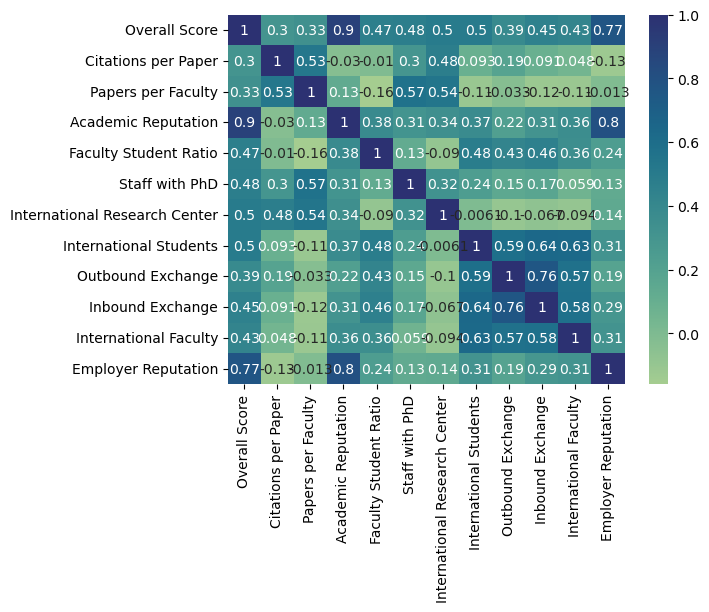

In [48]:
sns.heatmap(corr_df.corr(),
            cmap="crest",
            annot=True)

### Insight

The correlation analysis shows that Academic Reputation and Employer Reputation
have the strongest relationships with the Overall Score. This suggests that
reputation-related factors play a major role in university rankings.

## Conclusion

This analysis explored the QS Asian University Rankings dataset to
understand patterns and factors influencing university performance in Asia.

1. Which countries have the most universities in the ranking?

The analysis shows that China has the largest number of universities in the ranking compared to others.
This suggests that this country have a strong presence in higherceducation across Asia.

2. How are university scores distributed?

University scores vary across countries. Some countries have higher
median scores and more consistent performance such as Singapore and Hongkong, while others show
greater variation, indicating differences in university performance
within those countries.

3. What factors correlate with university rankings?

The correlation analysis reveals that Academic Reputation and
Employer Reputation have the strongest positive relationships
with the Overall Score.

4. Are research metrics related to overall scores?

Research-related metrics such as Citations per Paper show a positive
relationship with the overall score. This suggests that research
impact may contribute to higher university rankings, although it
is not the only factor influencing the results.

### 